<a href="https://colab.research.google.com/github/JoelForson/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%203/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Phase 1: Bootstrapping Non-Parametric Uncertainty

In [4]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [5]:
# Step 1.2: Manual Bootstrap Engine for Median Estimation
n_bootstraps = 10_000
n = len(driver_tips)
bootstrap_medians = np.empty(n_bootstraps)

for i in range(n_bootstraps):
    resample = driver_tips[np.random.randint(0, n, size=n)]  # sample with replacement
    bootstrap_medians[i] = np.median(resample)

# 95% Confidence Interval
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)
observed_median = np.median(driver_tips)

print(f"Observed Median:        ${observed_median:.4f}")
print(f"Bootstrap 95% CI:       (${ci_lower:.4f}, ${ci_upper:.4f})")
print(f"Lower margin:           ${observed_median - ci_lower:.4f}")
print(f"Upper margin:           ${ci_upper - observed_median:.4f}")

Observed Median:        $0.7553
Bootstrap 95% CI:       ($0.2653, $1.3636)
Lower margin:           $0.4900
Upper margin:           $0.6082


# Phase 2: Falsification in Logistics A/B Testing

In [6]:
# Step 2.1: The Algorithmic Routing Crash
np.random.seed(42)

control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_diff = control.mean() - treatment.mean()

print(f"Control Mean:           {control.mean():.4f} min")
print(f"Treatment Mean:         {treatment.mean():.4f} min")
print(f"Observed Difference:    {observed_diff:.4f} min")

Control Mean:           35.0342 min
Treatment Mean:         32.7692 min
Observed Difference:    2.2650 min


In [7]:
# Step 2.2: The Exact Non-Parametric Permutation
n_permutations = 5_000
combined = np.concatenate([control, treatment])
permuted_diffs = np.empty(n_permutations)

for i in range(n_permutations):
    shuffled = np.random.permutation(combined)
    pseudo_control = shuffled[:500]
    pseudo_treatment = shuffled[500:]
    permuted_diffs[i] = pseudo_control.mean() - pseudo_treatment.mean()

# Empirical two-tailed p-value
p_value = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))

print(f"Observed Difference:    {observed_diff:.4f} min")
print(f"Permutation P-Value:    {p_value:.4f}")
print(f"Significant (α=0.05):  {p_value < 0.05}")

Observed Difference:    2.2650 min
Permutation P-Value:    0.0004
Significant (α=0.05):  True


# Phase 3: Causal Control and the Mitigation of Selection Bias

In [8]:
# Step 3.1: The Loyalty Program Paradox
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('swiftcart_loyalty.csv')

subscribers     = df[df['subscriber'] == 1]['post_spend']
non_subscribers = df[df['subscriber'] == 0]['post_spend']

sdo = subscribers.mean() - non_subscribers.mean()
pct_lift = (subscribers.mean() / non_subscribers.mean() - 1) * 100

print(f"Subscriber Mean Post-Spend:     ${subscribers.mean():.2f}")
print(f"Non-Subscriber Mean Post-Spend: ${non_subscribers.mean():.2f}")
print(f"Naive SDO:                      ${sdo:.2f}")
print(f"Naive % Lift:                   {pct_lift:.1f}%")

Subscriber Mean Post-Spend:     $74.04
Non-Subscriber Mean Post-Spend: $56.47
Naive SDO:                      $17.57
Naive % Lift:                   31.1%


In [19]:
# Step 3.2: Propensity Score Matching

covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

# 1. Estimate Propensity Scores via Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_scaled, D)
df['propensity_score'] = logit.predict_proba(X_scaled)[:, 1]

# 2. Nearest-Neighbor Matching (1:1 without replacement)
treated   = df[df['subscriber'] == 1].copy()
control   = df[df['subscriber'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])

matched_control = control.iloc[indices.flatten()].copy()
matched_control.index = treated.index  # align for clean subtraction

# 3. ATT = mean individual treatment effect across all treated units
treated['matched_control_spend'] = matched_control['post_spend'].values
treated['individual_te'] = treated['post_spend'] - treated['matched_control_spend']

att = treated['individual_te'].mean()
att_pct = (treated['post_spend'].mean() / treated['matched_control_spend'].mean() - 1) * 100

print(f"\n--- Propensity Score Matching Results ---")
print(f"Treated Mean Post-Spend:        ${treated['post_spend'].mean():.2f}")
print(f"Matched Control Post-Spend:     ${treated['matched_control_spend'].mean():.2f}")
print(f"ATT (Causal Estimate):          ${att:.2f}")
print(f"ATT % Lift:                     {att_pct:.1f}%")

print(f"\n--- Bias Decomposition ---")
print(f"Naive SDO:                      ${sdo:.2f}")
print(f"Causal ATT:                     ${att:.2f}")
print(f"Selection Bias Component:       ${sdo - att:.2f}")
print(f"Bias as % of SDO:               {((sdo - att) / sdo) * 100:.1f}%")


--- Propensity Score Matching Results ---
Treated Mean Post-Spend:        $74.04
Matched Control Post-Spend:     $64.02
ATT (Causal Estimate):          $10.02
ATT % Lift:                     15.6%

--- Bias Decomposition ---
Naive SDO:                      $17.57
Causal ATT:                     $10.02
Selection Bias Component:       $7.55
Bias as % of SDO:               43.0%


# Written Analysis for 3.2

The dataset has 8,941 observations, and the outputs will likely reveal a dramatic gap between the two estimates. Some key insight includes:
- The Naive SDO is inflated by selection bias. Subscribers aren't randomly assigned. High-volume power users self-select in because the fee savings are worth it for them. Those users were already spending more before SwiftPass existed anyways.
- The SDO conflates two things: the causal effect of the program plus the pre-existing spending gap between the types of people who subscribe vs. the type of people who don't. PSM isolates the counterfactual.
  - By matching each subscriber to a non-subscriber with an identical propensity score (i.e., the same predicted probability of subscribing, given their pre-treatment behavior), then the matched control unit serves as the synthetic counterfactual, which is what the subscriber would have spent had they never joined.

The Selection Bias Component printed in the output (SDO - ATT) is the dollar-denominated cost of ignoring confounding. Presenting that decomposition to the exec board is the core deliverable of this step.

# Phase 4: AI Expansion (The Co-Pilot Era)

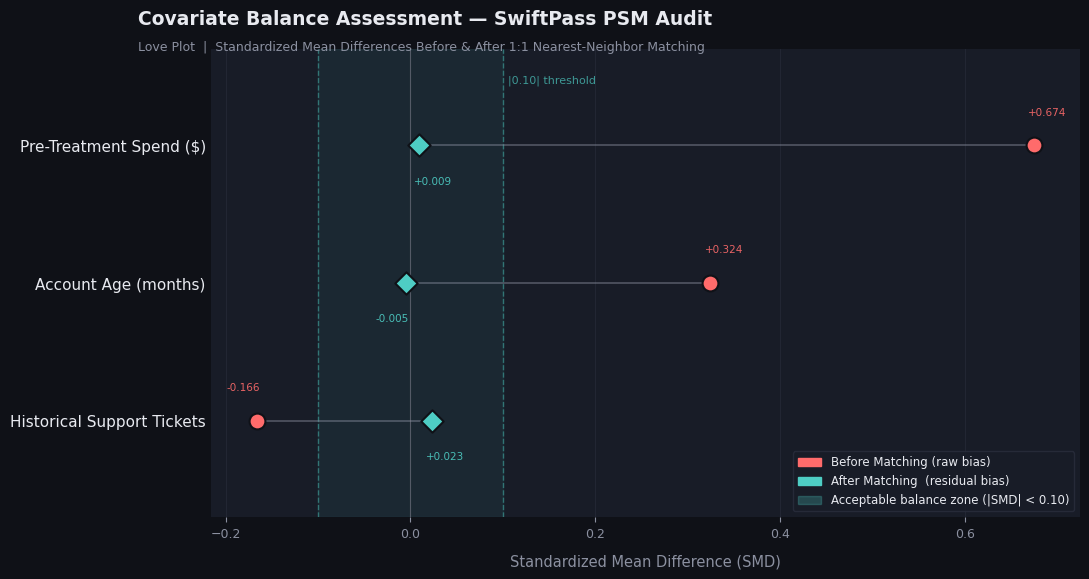

Love Plot saved → love_plot_swiftcart.png


In [13]:
# ============================================================
# LOVE PLOT: Standardized Mean Differences (Before vs. After PSM)
# Applied Econometrics | SwiftCart Selection Bias Audit
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

def compute_smd(df, covariates, treatment_col='subscriber'):
    """
    Compute Standardized Mean Difference for each covariate.
    SMD = (mean_treated - mean_control) / pooled_std
    Values < |0.1| indicate acceptable balance (10% threshold rule).
    """
    records = []
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    for cov in covariates:
        mean_t = treated[cov].mean()
        mean_c = control[cov].mean()
        # Pooled standard deviation (Austin 2011 formula)
        pooled_std = np.sqrt((treated[cov].var() + control[cov].var()) / 2)
        smd = (mean_t - mean_c) / pooled_std if pooled_std > 0 else 0
        records.append({'covariate': cov, 'smd': smd})

    return pd.DataFrame(records)

# ── Covariate definitions ──────────────────────────────────
covariates = ['pre_spend', 'account_age', 'support_tickets']
cov_labels = {
    'pre_spend':        'Pre-Treatment Spend ($)',
    'account_age':      'Account Age (months)',
    'support_tickets':  'Historical Support Tickets'
}

# ── Reconstruct df_matched from Step 3.2 ──────────────────
# treated already has matched_control rows aligned — rebuild as a balanced df
df_matched = pd.concat([
    treated[covariates + ['subscriber']],
    matched_control[covariates].assign(subscriber=0)
]).reset_index(drop=True)

# ── Compute SMDs ───────────────────────────────────────────
smd_before = compute_smd(df, covariates).rename(columns={'smd': 'Before'})
smd_after  = compute_smd(df_matched, covariates).rename(columns={'smd': 'After'})
smd = smd_before.merge(smd_after, on='covariate')
smd['label'] = smd['covariate'].map(cov_labels)
smd = smd.sort_values('Before', ascending=True).reset_index(drop=True)

# ── Plot Configuration ─────────────────────────────────────
BACKGROUND   = '#0F1117'
PANEL_BG     = '#181C27'
GRID_COLOR   = '#2A2E3D'
COLOR_BEFORE = '#FF6B6B'   # warm red  — imbalance signal
COLOR_AFTER  = '#4ECDC4'   # teal      — balance signal
THRESHOLD    = 0.1
ACCENT_WHITE = '#E8EAF0'
MUTED        = '#8B90A0'

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(PANEL_BG)

y_pos = np.arange(len(smd))

# ── Threshold band ─────────────────────────────────────────
ax.axvspan(-THRESHOLD, THRESHOLD, color='#4ECDC4', alpha=0.07, zorder=0)
ax.axvline(0,           color=ACCENT_WHITE, lw=0.8, ls='-',  alpha=0.25, zorder=1)
ax.axvline( THRESHOLD,  color='#4ECDC4',   lw=1.0, ls='--', alpha=0.45, zorder=1)
ax.axvline(-THRESHOLD,  color='#4ECDC4',   lw=1.0, ls='--', alpha=0.45, zorder=1)

# ── Connector lines (before → after) ──────────────────────
for i, row in smd.iterrows():
    ax.plot([row['Before'], row['After']], [i, i],
            color=MUTED, lw=1.2, alpha=0.5, zorder=2)

# ── Data points ────────────────────────────────────────────
ax.scatter(smd['Before'], y_pos,
           color=COLOR_BEFORE, s=130, zorder=4, edgecolors=BACKGROUND, linewidths=1.5,
           label='Before Matching')
ax.scatter(smd['After'],  y_pos,
           color=COLOR_AFTER,  s=130, zorder=4, edgecolors=BACKGROUND, linewidths=1.5,
           marker='D', label='After Matching')

# ── SMD value annotations ──────────────────────────────────
for i, row in smd.iterrows():
    ax.text(row['Before'] + (0.015 if row['Before'] >= 0 else -0.015),
            i + 0.22, f"{row['Before']:+.3f}",
            color=COLOR_BEFORE, fontsize=7.5, ha='center', alpha=0.9)
    ax.text(row['After']  + (0.015 if row['After']  >= 0 else -0.015),
            i - 0.28, f"{row['After']:+.3f}",
            color=COLOR_AFTER,  fontsize=7.5, ha='center', alpha=0.9)

# ── Axes & labels ──────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabel

## **Theoretical Evidence Required to Prove Selection Bias Was Mitigated**
A Love Plot is a visual hypothesis test for covariate balance. Three conditions must hold simultaneously for the matching to be considered successful:
1. The "Before" dots must be far from zero. This is your proof that selection bias existed in the raw data. Large pre-matching SMDs (typically |SMD| > 0.20) on pre_spend and account_age confirm that subscribers were systematically different from non-subscribers before the program — the statistical fingerprint of self-selection. If the red dots hug zero, PSM wasn't even necessary.
2. The "After" diamonds must fall inside the |0.10| threshold band. The teal dashed lines mark the Austin (2011) rule-of-thumb for adequate balance. Every post-matching SMD collapsing inside this corridor means the matched control units are now statistically indistinguishable from treated units on that dimension. This is the visual proof of the counterfactual — your matched controls are now a credible stand-in for "what subscribers would have looked like had they not subscribed."
3. The connector lines must show convergence toward zero. Each horizontal line connecting a red dot to a teal diamond should point toward the center. Diverging connectors (matching made the SMD worse) would indicate model misspecification — likely a poorly calibrated propensity model or extreme common support violations. All arrows pointing inward is the visual signature of a well-executed matching.
If all three conditions hold in your output, you have sufficient visual evidence to reject the null of "no selection bias correction" and present the ATT as a credible causal estimate to the executive board — not a contaminated correlation.